# Two-Step Floating Catchment Area (2SFCA) Accessibility Analysis
## Pharmacy Access in Gauteng and KwaZulu-Natal, South Africa

**Tess Vu**

This notebook computes a **pharmacy accessibility score** for every Small Area Layer (SAL) in Gauteng and KwaZulu-Natal using the Two-Step Floating Catchment Area (2SFCA) method with network-based routing. It is a rough derivation from Jillian's original `2sfca.ipynb` notebook now located in the `archive/` folder.

**What the score means:** A higher score indicates better pharmacy access. A score of zero means no registered pharmacy is reachable within the travel distance on the road network.

**How it works (two steps):**
1. **Step 1 (Supply side):** For each pharmacy, travel outward on the road network up to a cutoff distance. Count the decay-weighted population of all neighborhoods within reach. Compute a supply-to-demand ratio (Rj).
2. **Step 2 (Demand side):** For each neighborhood, travel outward on the road network. Sum the supply ratios (Rj) of all reachable pharmacies, weighted by distance decay. The result is the accessibility score (Ai).

**Four runs:** Walk and drive networks for each province, with catchment distances reflecting the different settlement patterns:
- **Gauteng** (dense, urban): 2 km walk / 5 km drive
- **KwaZulu-Natal** (sparse, rural): 3 km walk / 10 km drive

The asymmetric thresholds are intentional. KZN is ~7x larger than Gauteng and much less densely populated. Residents in rural/traditional KZN areas travel longer distances for medicine as a matter of daily life.

## SETUP AND IMPORTS

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
import osmnx as ox
import networkx as nx
from tqdm import tqdm
from shapely.geometry import Point
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
# Register Space Mono fonts
for f in [
    "data/Space_Mono/SpaceMono-Regular.ttf",
    "data/Space_Mono/SpaceMono-Bold.ttf",
    "data/Space_Mono/SpaceMono-Italic.ttf",
    "data/Space_Mono/SpaceMono-BoldItalic.ttf",
]:
    fm.fontManager.addfont(f)

# Register Space Grotesk fonts
for f in [
    "data/Space_Grotesk/static/SpaceGrotesk-Regular.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Medium.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Bold.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-Light.ttf",
    "data/Space_Grotesk/static/SpaceGrotesk-SemiBold.ttf",
]:
    fm.fontManager.addfont(f)

FONT_TITLE  = "Space Mono"    # titles, subtitles, legend titles
FONT_BODY   = "Space Grotesk" # axis labels, tick labels, legend item labels

# Global rcParams — body font as default, override titles manually
plt.rcParams.update({
    "font.family":           FONT_BODY,
    "axes.titlesize":        14,
    "axes.labelsize":        11,
    "xtick.labelsize":       10,
    "ytick.labelsize":       10,
    "legend.fontsize":       10,
    "legend.title_fontsize": 11,
})

print(f"Space Mono available: {'Space Mono' in [f.name for f in fm.fontManager.ttflist]}")
print(f"Space Grotesk available: {'Space Grotesk' in [f.name for f in fm.fontManager.ttflist]}")

Space Mono available: True
Space Grotesk available: True


## LOAD SOURCE DATA

Two main datasets:
- **SAL population estimates** (`pop_pred_final.csv`): ~38,000 Small Area Layers with 2023 population estimates from a dasymetric step-down model.
- **Pharmacy locations** (`PHARMACIES_MASTER_FINAL.csv`): Deduplicated and geocoded pharmacy dataset combining multiple insurer sources.

In [3]:
# Load population and pharmacy data.
sal_raw = pd.read_csv("data/pop_pred_final.csv")
pharmacy_raw = pd.read_csv("data/PHARMACIES_MASTER_FINAL.csv")

# Load SAL geographic boundaries (polygons and centroids).
sal_centroids = gpd.read_file("data/2011_census/2011_ea_sal_centroids_kzn_gp/2011_ea_sal_centroids_kzn_gp.shp")
sal_polygons = gpd.read_file("data/2011_census/2011_census/ea_sal_kzn_gp.shp")

pd.reset_option("display.float_format")

## PREPARE PHARMACY AND SAL GEODATAFRAMES

Convert pharmacy coordinates into a spatial GeoDataFrame, merge SAL population data with boundaries, and filter out SALs with population below 100 (uninhabited areas like farms and nature reserves).

In [4]:
# Convert pharmacy table to a spatial GeoDataFrame.
pharmacy_gdf = gpd.GeoDataFrame(
    pharmacy_raw,
    geometry = gpd.points_from_xy(pharmacy_raw["LNG"], pharmacy_raw["LAT"]),
    crs = "EPSG:4326"
)
pharmacy_gdf = pharmacy_gdf.to_crs(sal_polygons.crs)

# Normalize EA_CODE to int64 on both sides to avoid int/float merge warning.
sal_raw["EA_CODE"] = pd.to_numeric(sal_raw["EA_CODE"], errors = "coerce").astype("int64")
sal_polygons["EA_CODE"] = pd.to_numeric(sal_polygons["EA_CODE"], errors = "coerce").astype("int64")

# Merge SAL population data with polygon geometries.
sal = sal_raw.merge(
    sal_polygons[["EA_CODE", "PR_NAME", "geometry"]],
    on = "EA_CODE",
    how = "left"
)
sal = gpd.GeoDataFrame(sal, geometry = "geometry")

# Filter out SALs with population below 100.
#sal = sal[sal["sal2023_est"] >= 100].copy()
print(f"SALs: {len(sal)}")

SALs: 41329


## VARIABLE CATCHMENT (OPTIONAL, COMMENTED OUT)

An alternative to fixed per-province catchment distances is to assign catchments based on each SAL's settlement type (Urban, Traditional, Other). Something to strongly consider, but need to take a closer look at the settlement types and their distribution across the two provinces before implementing.

**If enabled:** replace the hardcoded `cutoff` values in each 2SFCA call with per-SAL catchment distances. The 2SFCA loop structure would need modification to read each SAL's individual catchment.

In [5]:
# VARIABLE_CATCHMENT = True

# def assign_catchment(row):
#     """Assign catchment distance (meters) based on settlement type."""
#     if row["EA_GTYPE"] == "Urban":
#         return 2000
#     elif row["EA_GTYPE"] == "Traditional":
#         return 10000
#     else:
#         return 15000

# sal["catchment"] = sal.apply(assign_catchment, axis = 1)
# print(f"CATCHMENT DISTRIBUTION")
# print(sal.groupby("EA_GTYPE")["catchment"].first())

## SPLIT BY PROVINCE AND ASSIGN PHARMACIES

In [6]:
# Split SALs by province.
kzn_sal = sal[sal["PR_NAME"] == "KwaZulu-Natal"].copy()
gau_sal = sal[sal["PR_NAME"] == "Gauteng"].copy()

# Spatial join: identify pharmacies within each province.
kzn_pharmacies = gpd.sjoin(pharmacy_gdf, kzn_sal, predicate = "within")
gau_pharmacies = gpd.sjoin(pharmacy_gdf, gau_sal, predicate = "within")

print(f"KZN SALs: {len(kzn_sal)}  |  KZN Pharmacies: {len(kzn_pharmacies)}")
print(f"GAU SALs: {len(gau_sal)}  |  GAU Pharmacies: {len(gau_pharmacies)}")

KZN SALs: 17988  |  KZN Pharmacies: 707
GAU SALs: 21180  |  GAU Pharmacies: 1474


## PREVIEW: SAL BOUNDARIES WITH PHARMACY LOCATIONS

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (16, 8))
fig.patch.set_alpha(0.0)

kzn_sal.plot(ax = axes[0], color = "#dac291", edgecolor = "#f9eece", linewidth = 0.3)
kzn_pharmacies.plot(ax = axes[0], color = "#2e3e6c", markersize = 3, alpha = 1)
axes[0].set_title("KwaZulu-Natal: SALs and Pharmacies", fontfamily = FONT_TITLE, fontweight = "bold")
axes[0].set_facecolor("none")
axes[0].axis("off")

gau_sal.plot(ax = axes[1], color = "#dac291", edgecolor = "#f9eece", linewidth = 0.3)
gau_pharmacies.plot(ax = axes[1], color = "#2e3e6c", markersize = 3, alpha = 1)
axes[1].set_title("Gauteng: SALs and Pharmacies", fontfamily = FONT_TITLE, fontweight = "bold")
axes[1].set_facecolor("none")
axes[1].axis("off")

plt.tight_layout()
fig.patch.set_alpha(0.0)
fig.savefig("images/2sfca_province_preview.png", dpi = 300, bbox_inches = "tight", transparent = True)
plt.show()

## DISTANCE DECAY FUNCTION

**Previous version used beta = 0.0001**, which produced almost no decay, so a pharmacy 10 km away still received 37% weight, and essentially the model could barely
distinguish near from far.

**Updated to beta = 0.0003** for meaningful distance discrimination:

| Distance | Weight |
|----------|--------|
| 0 m      | 1.000  |
| 1 km     | 0.741  |
| 2 km     | 0.549  |
| 3 km     | 0.407  |
| 5 km     | 0.223  |
| 10 km    | 0.050  |

In [8]:
def decay(distance, beta = 0.0003):
    """Negative exponential distance decay function."""
    return np.exp(-beta * distance)

## 2SFCA COMPUTATION FUNCTION

Contains two bug fixes from the previous version:

**Fix 1 - Node collision:** The old code used `.set_index("node")` to build the population lookup, so when multiple SALs snapped to the same road node, only one SAL's population was kept. The fix uses `.groupby("node").sum()` to add all populations together.

**Fix 2 - Rj outlier cap:** A pharmacy with only 3 people in its catchment produced Rj = 1000/3 = 333, creating scores 5,000x the mean. A minimum population floor of 50 prevents these runaway ratios.

In [9]:
MIN_WEIGHTED_POP = 50

def run_2sfca(sal_gdf, pharm_gdf, graph, cutoff_meters, score_column):
    """Run both steps of the 2SFCA for one province/mode combination.

    Parameters
    ----------
    sal_gdf : GeoDataFrame with "node" and "sal2023_est" columns.
    pharm_gdf : GeoDataFrame with "node" column.
    graph : Projected OSMnx road network.
    cutoff_meters : Maximum network travel distance for catchment.
    score_column : Name of the output column (e.g. "Ai_walk").
    """
    # FIX 1: groupby-sum handles node collisions (old code used set_index
    # which silently dropped populations when SALs shared a network node).
    pop_dict = sal_gdf.groupby("node")["sal2023_est"].sum().to_dict()

    # STEP 1: Calculate supply-to-demand ratio (Rj) for each pharmacy.
    print(f"STEP 1: Computing Rj for {len(pharm_gdf)} pharmacies (cutoff = {cutoff_meters}m)")
    rj_list = []

    for idx, pharm in tqdm(pharm_gdf.iterrows(), total = len(pharm_gdf)):
        # Dijkstra traversal outward from this pharmacy.
        lengths = nx.single_source_dijkstra_path_length(
            graph, pharm["node"], cutoff = cutoff_meters, weight = "length"
        )

        # Sum decay-weighted population of all reachable SALs.
        weighted_pop = sum(
            pop_dict.get(node, 0) * decay(dist)
            for node, dist in lengths.items()
        )

        # FIX 2: Floor prevents near-infinite Rj from sparse catchments.
        if weighted_pop > 0:
            rj = 1 / (max(weighted_pop, MIN_WEIGHTED_POP) / 1000)
        else:
            rj = 0
        rj_list.append(rj)

    pharm_gdf["Rj"] = rj_list
    pharm_dict = pharm_gdf.groupby("node")["Rj"].sum().to_dict()

    # STEP 2: Calculate accessibility score (Ai) for each SAL.
    print(f"STEP 2: Computing Ai for {len(sal_gdf)} SALs")
    ai_list = []

    for idx, pop in tqdm(sal_gdf.iterrows(), total = len(sal_gdf)):
        lengths = nx.single_source_dijkstra_path_length(
            graph, pop["node"], cutoff = cutoff_meters, weight = "length"
        )
        ai = sum(
            pharm_dict.get(node, 0) * decay(dist)
            for node, dist in lengths.items()
        )
        ai_list.append(ai)

    sal_gdf[score_column] = ai_list
    print(f"COMPLETE: {score_column}")
    print(sal_gdf[score_column].describe())
    return sal_gdf

## KWAZULU-NATAL: WALKING ACCESSIBILITY (3 km catchment)

Graph loading is slow. The raw graph is loaded once into a static variable.
All transformations (projection) are saved into separate variables.

In [10]:
# Load raw graph once (SLOW AF STEP - PLEAK DO NOT RE-RUN `load_graphml` CELLS UNNECESSARILY).
kzn_walk_graph_raw = ox.load_graphml("data/networks/network_kwazulu_natal_walk.graphml")
print(f"KZN walk RAW: {kzn_walk_graph_raw.number_of_nodes()} nodes, {kzn_walk_graph_raw.number_of_edges()} edges")

KZN walk RAW: 541204 nodes, 1356318 edges


In [11]:
# Project into a working copy.
kzn_walk_graph = ox.project_graph(kzn_walk_graph_raw, to_crs = "EPSG:32735")
print(f"KZN walk PROJECTED: {kzn_walk_graph.number_of_nodes()} nodes, {kzn_walk_graph.number_of_edges()} edges")

kzn_sal = kzn_sal.to_crs(kzn_walk_graph.graph["crs"])
kzn_sal = kzn_sal.set_geometry(kzn_sal.geometry.centroid)
kzn_pharmacies = kzn_pharmacies.to_crs(kzn_walk_graph.graph["crs"])

kzn_sal["node"] = ox.nearest_nodes(kzn_walk_graph, kzn_sal.geometry.x, kzn_sal.geometry.y)
kzn_walk_pharm = kzn_pharmacies.copy()
kzn_walk_pharm["node"] = ox.nearest_nodes(kzn_walk_graph, kzn_walk_pharm.geometry.x, kzn_walk_pharm.geometry.y)

KZN walk PROJECTED: 541204 nodes, 1356318 edges


In [12]:
kzn_sal = run_2sfca(kzn_sal, kzn_walk_pharm, kzn_walk_graph, cutoff_meters = 3000, score_column = "Ai_walk")

STEP 1: Computing Rj for 707 pharmacies (cutoff = 3000m)


100%|██████████| 707/707 [00:09<00:00, 74.34it/s]


STEP 2: Computing Ai for 17988 SALs


100%|██████████| 17988/17988 [01:38<00:00, 182.48it/s]

COMPLETE: Ai_walk
count    17988.000000
mean         0.083982
std          0.253220
min          0.000000
25%          0.000000
50%          0.000000
75%          0.053183
max         17.955873
Name: Ai_walk, dtype: float64


In [13]:
kzn_sal["Ai_walk"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    17988.000000
mean         0.083982
std          0.253220
min          0.000000
90%          0.258273
95%          0.489196
98%          0.768293
99%          0.968128
99.9%        2.237138
max         17.955873
Name: Ai_walk, dtype: float64

## KWAZULU-NATAL: DRIVING ACCESSIBILITY (10 km catchment)

In [14]:
kzn_drive_graph_raw = ox.load_graphml("data/networks/network_kwazulu_natal_drive.graphml")
print(f"KZN drive RAW: {kzn_drive_graph_raw.number_of_nodes()} nodes, {kzn_drive_graph_raw.number_of_edges()} edges")

KZN drive RAW: 311426 nodes, 749194 edges


In [15]:
kzn_drive_graph = ox.project_graph(kzn_drive_graph_raw, to_crs = "EPSG:32735")
print(f"KZN drive PROJECTED: {kzn_drive_graph.number_of_nodes()} nodes, {kzn_drive_graph.number_of_edges()} edges")

kzn_sal = kzn_sal.to_crs(kzn_drive_graph.graph["crs"])
kzn_pharmacies = kzn_pharmacies.to_crs(kzn_drive_graph.graph["crs"])

kzn_sal["node"] = ox.nearest_nodes(kzn_drive_graph, kzn_sal.geometry.x, kzn_sal.geometry.y)
kzn_drive_pharm = kzn_pharmacies.copy()
kzn_drive_pharm["node"] = ox.nearest_nodes(kzn_drive_graph, kzn_drive_pharm.geometry.x, kzn_drive_pharm.geometry.y)

KZN drive PROJECTED: 311426 nodes, 749194 edges


In [16]:
kzn_sal = run_2sfca(kzn_sal, kzn_drive_pharm, kzn_drive_graph, cutoff_meters = 10000, score_column = "Ai_drive")

STEP 1: Computing Rj for 707 pharmacies (cutoff = 10000m)


100%|██████████| 707/707 [00:29<00:00, 24.13it/s]


STEP 2: Computing Ai for 17988 SALs


100%|██████████| 17988/17988 [07:14<00:00, 41.37it/s] 

COMPLETE: Ai_drive
count    17988.000000
mean         0.069131
std          0.116416
min          0.000000
25%          0.000000
50%          0.017144
75%          0.095177
max          3.803791
Name: Ai_drive, dtype: float64


In [17]:
kzn_sal["Ai_drive"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    17988.000000
mean         0.069131
std          0.116416
min          0.000000
90%          0.206243
95%          0.309429
98%          0.403641
99%          0.465205
99.9%        0.909659
max          3.803791
Name: Ai_drive, dtype: float64

## GAUTENG: WALKING ACCESSIBILITY (2 km catchment)

In [18]:
gau_walk_graph_raw = ox.load_graphml("data/networks/network_gauteng_walk.graphml")
print(f"GAU walk RAW: {gau_walk_graph_raw.number_of_nodes()} nodes, {gau_walk_graph_raw.number_of_edges()} edges")

GAU walk RAW: 443832 nodes, 1219312 edges


In [19]:
gau_walk_graph = ox.project_graph(gau_walk_graph_raw, to_crs = "EPSG:32735")
print(f"GAU walk PROJECTED: {gau_walk_graph.number_of_nodes()} nodes, {gau_walk_graph.number_of_edges()} edges")

gau_sal = gau_sal.to_crs(gau_walk_graph.graph["crs"])
gau_sal = gau_sal.set_geometry(gau_sal.geometry.centroid)
gau_pharmacies = gau_pharmacies.to_crs(gau_walk_graph.graph["crs"])

gau_sal["node"] = ox.nearest_nodes(gau_walk_graph, gau_sal.geometry.x, gau_sal.geometry.y)
gau_walk_pharm = gau_pharmacies.copy()
gau_walk_pharm["node"] = ox.nearest_nodes(gau_walk_graph, gau_walk_pharm.geometry.x, gau_walk_pharm.geometry.y)

GAU walk PROJECTED: 443832 nodes, 1219312 edges


In [20]:
gau_sal = run_2sfca(gau_sal, gau_walk_pharm, gau_walk_graph, cutoff_meters = 2000, score_column = "Ai_walk")

STEP 1: Computing Rj for 1474 pharmacies (cutoff = 2000m)


100%|██████████| 1474/1474 [00:11<00:00, 129.41it/s]


STEP 2: Computing Ai for 21180 SALs


100%|██████████| 21180/21180 [01:56<00:00, 181.39it/s]

COMPLETE: Ai_walk
count    21180.000000
mean         0.163272
std          0.444752
min          0.000000
25%          0.000000
50%          0.038221
75%          0.183422
max         42.701682
Name: Ai_walk, dtype: float64


In [21]:
gau_sal["Ai_walk"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    21180.000000
mean         0.163272
std          0.444752
min          0.000000
90%          0.488460
95%          0.721923
98%          1.090779
99%          1.382243
99.9%        2.665191
max         42.701682
Name: Ai_walk, dtype: float64

## GAUTENG: DRIVING ACCESSIBILITY (5 km catchment)

In [22]:
gau_drive_graph_raw = ox.load_graphml("data/networks/network_gauteng_drive.graphml")
print(f"GAU drive RAW: {gau_drive_graph_raw.number_of_nodes()} nodes, {gau_drive_graph_raw.number_of_edges()} edges")

GAU drive RAW: 279004 nodes, 730792 edges


In [23]:
gau_drive_graph = ox.project_graph(gau_drive_graph_raw)
print(f"GAU drive PROJECTED: {gau_drive_graph.number_of_nodes()} nodes, {gau_drive_graph.number_of_edges()} edges")

gau_sal = gau_sal.to_crs(gau_drive_graph.graph["crs"])
gau_pharmacies = gau_pharmacies.to_crs(gau_drive_graph.graph["crs"])

gau_sal["node"] = ox.nearest_nodes(gau_drive_graph, gau_sal.geometry.x, gau_sal.geometry.y)
gau_drive_pharm = gau_pharmacies.copy()
gau_drive_pharm["node"] = ox.nearest_nodes(gau_drive_graph, gau_drive_pharm.geometry.x, gau_drive_pharm.geometry.y)

GAU drive PROJECTED: 279004 nodes, 730792 edges


In [24]:
gau_sal = run_2sfca(gau_sal, gau_drive_pharm, gau_drive_graph, cutoff_meters = 5000, score_column = "Ai_drive")

STEP 1: Computing Rj for 1474 pharmacies (cutoff = 5000m)


100%|██████████| 1474/1474 [00:29<00:00, 50.41it/s]


STEP 2: Computing Ai for 21180 SALs


100%|██████████| 21180/21180 [06:27<00:00, 54.66it/s]

COMPLETE: Ai_drive
count    21180.000000
mean         0.190574
std          0.391659
min          0.000000
25%          0.021517
50%          0.054774
75%          0.246242
max          8.332970
Name: Ai_drive, dtype: float64


In [25]:
gau_sal["Ai_drive"].describe(percentiles = [0.9, 0.95, 0.98, 0.99, 0.999])

count    21180.000000
mean         0.190574
std          0.391659
min          0.000000
90%          0.441608
95%          0.652265
98%          1.129273
99%          2.017643
99.9%        4.144137
max          8.332970
Name: Ai_drive, dtype: float64

## SCORE DISTRIBUTION HISTOGRAMS

In [ ]:
fig, axes = plt.subplots(2, 2, figsize = (14, 10))

formatter = FuncFormatter(lambda x, p: f"{int(x):,}")

#fig.patch.set_facecolor("#fcffeb")

kzn_sal["Ai_walk"].hist(ax = axes[0, 0], bins = 50, color = "#2e3e6c", edgecolor = "white")
#axes[0, 0].set_facecolor("#fcffeb")
axes[0, 0].yaxis.set_major_formatter(formatter)
axes[0, 0].set_title("KZN Walk Accessibility ($A_{i}$)", fontweight = "bold")
axes[0, 0].set_xlabel("Accessibility Index ($A_{i}$)", fontweight = "bold")

kzn_sal["Ai_drive"].hist(ax = axes[0, 1], bins = 50, color = "#ffcb05", edgecolor = "white")
#axes[0, 1].set_facecolor("#fcffeb")
axes[0, 1].yaxis.set_major_formatter(formatter)
axes[0, 1].set_title("KZN Drive Accessibility ($A_{i}$)", fontweight = "bold")
axes[0, 1].set_xlabel("Accessibility Index ($A_{i}$)", fontweight = "bold")

gau_sal["Ai_walk"].hist(ax = axes[1, 0], bins = 50, color = "#2e3e6c", edgecolor = "white")
#axes[1, 0].set_facecolor("#fcffeb")
axes[1, 0].yaxis.set_major_formatter(formatter)
axes[1, 0].set_title("Gauteng Walk Accessibility ($A_{i}$)", fontweight = "bold")
axes[1, 0].set_xlabel("Accessibility Index ($A_{i}$)", fontweight = "bold")

gau_sal["Ai_drive"].hist(ax = axes[1, 1], bins = 50, color = "#ffcb05", edgecolor = "white")
#axes[1, 1].set_facecolor("#fcffeb")
axes[1, 1].yaxis.set_major_formatter(formatter)
axes[1, 1].set_title("Gauteng Drive Accessibility ($A_{i}$)", fontweight = "bold")
axes[1, 1].set_xlabel("Accessibility Index ($A_{i}$)", fontweight = "bold")

plt.suptitle("Accessibility Score Distributions by Province and Mode", fontsize = 14, fontweight = "bold")
plt.tight_layout()
fig.savefig("images/2sfca/A_i_histogram.png", dpi = 300, bbox_inches = "tight")
# fig.savefig("images/2sfca/A_i_histogram.png", dpi = 300, bbox_inches = "tight", transparent = True)
plt.show()

## COMBINE PROVINCES AND EXPORT

In [27]:
print("DUPLICATE EA_CODES IN SAL_POLYGONS:")
dup_mask = sal_polygons.duplicated(subset = "EA_CODE", keep = False)
print(f"Total duplicate rows: {dup_mask.sum()}")
print(f"Unique EA_CODEs with duplicates: {sal_polygons.loc[dup_mask, 'EA_CODE'].nunique()}")
print(sal_polygons[dup_mask][["OBJECTID", "EA_CODE"]].sort_values("EA_CODE").head(20))

DUPLICATE EA_CODES IN SAL_POLYGONS:
Total duplicate rows: 5785
Unique EA_CODEs with duplicates: 2836
     OBJECTID   EA_CODE
214     30760  50310024
264     29305  50310024
239     27448  50310044
237     28628  50310044
198     29327  50310063
197     29327  50310063
196     25882  50310064
106     26748  50310064
232     28116  50310073
227     27965  50310073
257     27939  50310086
256     27939  50310086
259     28570  50310093
260     25984  50310093
172     29152  50310099
173     29152  50310099
249     28674  50310113
170     27838  50310113
69      28763  50310126
68      28763  50310126


In [ ]:
# Compute percentile ranks within each province.
for province_sal in [kzn_sal, gau_sal]:
    for col in ["Ai_walk", "Ai_drive"]:
        rank_col = col.replace("Ai_", "") + "_rank"
        province_sal[rank_col] = 0.0
        nonzero = province_sal[col] > 0
        province_sal.loc[nonzero, rank_col] = province_sal.loc[nonzero, col].rank(pct = True)

# Log-transform scores for mapping.
for province_sal in [kzn_sal, gau_sal]:
    province_sal["walk_log"] = np.log1p(province_sal["Ai_walk"])
    province_sal["drive_log"] = np.log1p(province_sal["Ai_drive"])

# Combine both provinces.
allaccess = pd.concat([kzn_sal, gau_sal], ignore_index = True)
allaccess = allaccess.drop(columns = "geometry")

# Deduplicate sal_polygons before merging to prevent row multiplication from duplicate polygon records.
# Believe this discards polygon fragments and creates holes.
# sal_polygons_clean = sal_polygons.drop_duplicates(subset = "EA_CODE", keep = "first")

# Merges all fragments for each EA_CODE into a single MultiPolygon.
sal_polygons_clean = sal_polygons.dissolve(by = "EA_CODE").reset_index()

# Deduplicate allaccess on EA_CODE before merging back — keep = "last" retains rows with both Ai_walk and Ai_drive populated.
allaccess = allaccess.drop_duplicates(subset = "EA_CODE", keep = "last")

# Merge back with cleaned polygon boundaries.
allaccess = sal_polygons_clean.merge(allaccess, on = "EA_CODE", how = "left")

print(f"COMBINED DATASET AFTER DEDUPLICATION: {len(allaccess)} SALs")

# Fill NaN scores with 0.
score_cols = ["walk_log", "drive_log", "walk_rank", "drive_rank"]
allaccess[score_cols] = allaccess[score_cols].fillna(0)
for c in score_cols:
    allaccess[c] = pd.to_numeric(allaccess[c], errors = "coerce")

# Clean up duplicate columns from merges.
x_cols = [c for c in allaccess.columns if c.endswith("_x")]
y_cols = [c for c in allaccess.columns if c.endswith("_y")]
allaccess = allaccess.drop(columns = y_cols)
allaccess = allaccess.rename(columns = {c: c[:-2] for c in x_cols})

COMBINED DATASET AFTER DEDUPLICATION: 36228 SALs


In [29]:
# Export to CSV.
# Convert to plain DataFrame.
allaccess_export = allaccess.drop(columns="geometry")
# Mixed data artifacts from the SAL census data, decided to keep by casting to string.
allaccess_export["smallplace"] = allaccess_export["smallplace"].astype(str)
allaccess_export.to_csv(
    "data/tess_all_access.csv",
    index = False,
    float_format = "%.6f",
    na_rep = ""
)
print("EXPORTED: data/tess_all_access.csv")

EXPORTED: data/tess_all_access.csv


## CATEGORICAL ACCESSIBILITY CLASSIFICATION

Assigns each SAL to a policy-relevant tier. Tiers are computed **within each province** because the catchment thresholds are intentionally asymmetric. SALs with Ai = 0 (no reachable pharmacy) are folded into **Pharmacy Desert**.

| Tier | Definition | Policy Implication |
|------|-----------|-------------------|
| **Pharmacy Desert** | Ai = 0 or bottom third of non-zero scores. | No or very limited access. Priority for NHI infrastructure and accreditation. |
| **Moderate Access** | Middle third of non-zero scores. | Some formal-sector access, but gaps remain. |
| **Served** | Top third of non-zero scores. | Adequate formal pharmacy access. |

In [30]:
def classify_access(df, score_col, tier_col):
    """Classify SALs into accessibility tiers within a single province."""
    df[tier_col] = "Pharmacy Desert"
    nonzero_mask = df[score_col] > 0
    nonzero_scores = df.loc[nonzero_mask, score_col]

    if len(nonzero_scores) == 0:
        return df

    t33 = nonzero_scores.quantile(0.333)
    t66 = nonzero_scores.quantile(0.666)

    df.loc[nonzero_mask & (df[score_col] <= t33), tier_col] = "Pharmacy Desert"
    df.loc[nonzero_mask & (df[score_col] > t33) & (df[score_col] <= t66), tier_col] = "Moderate Access"
    df.loc[nonzero_mask & (df[score_col] > t66), tier_col] = "Served"
    return df

# Initialize columns BEFORE the loop so .loc can write into them.
allaccess["walk_tier"] = "Pharmacy Desert"
allaccess["drive_tier"] = "Pharmacy Desert"

for prov in allaccess["PR_NAME"].dropna().unique():
    prov_mask = allaccess["PR_NAME"] == prov

    classified = classify_access(allaccess.loc[prov_mask].copy(), "Ai_walk", "walk_tier")
    allaccess.loc[prov_mask, "walk_tier"] = classified["walk_tier"].values

    classified = classify_access(allaccess.loc[prov_mask].copy(), "Ai_drive", "drive_tier")
    allaccess.loc[prov_mask, "drive_tier"] = classified["drive_tier"].values

tier_order = ["Pharmacy Desert", "Moderate Access", "Served"]
allaccess["walk_tier"] = pd.Categorical(allaccess["walk_tier"], categories = tier_order, ordered = True)
allaccess["drive_tier"] = pd.Categorical(allaccess["drive_tier"], categories = tier_order, ordered = True)

print("WALK TIER COUNTS BY PROVINCE")
print(allaccess.groupby("PR_NAME")["walk_tier"].value_counts().unstack(fill_value = 0))
print()
print("DRIVE TIER COUNTS BY PROVINCE")
print(allaccess.groupby("PR_NAME")["drive_tier"].value_counts().unstack(fill_value = 0))

WALK TIER COUNTS BY PROVINCE
walk_tier      Pharmacy Desert  Moderate Access  Served
PR_NAME                                                
Gauteng                  10477             4601    4615
KwaZulu-Natal            12283             2123    2129

DRIVE TIER COUNTS BY PROVINCE
drive_tier     Pharmacy Desert  Moderate Access  Served
PR_NAME                                                
Gauteng                   7614             6030    6049
KwaZulu-Natal             9717             3404    3414


In [31]:
print("WALK TIER PERCENTAGES BY PROVINCE")
walk_pct = allaccess.groupby("PR_NAME")["walk_tier"].value_counts(normalize = True).unstack(fill_value = 0)
print((walk_pct * 100).round(1))
print()
print("DRIVE TIER PERCENTAGES BY PROVINCE")
drive_pct = allaccess.groupby("PR_NAME")["drive_tier"].value_counts(normalize = True).unstack(fill_value = 0)
print((drive_pct * 100).round(1))

WALK TIER PERCENTAGES BY PROVINCE
walk_tier      Pharmacy Desert  Moderate Access  Served
PR_NAME                                                
Gauteng                   53.2             23.4    23.4
KwaZulu-Natal             74.3             12.8    12.9

DRIVE TIER PERCENTAGES BY PROVINCE
drive_tier     Pharmacy Desert  Moderate Access  Served
PR_NAME                                                
Gauteng                   38.7             30.6    30.7
KwaZulu-Natal             58.8             20.6    20.6


## NOTE: TRANSIT ACCESSIBILITY (LOOKING INTO THIS)

The walk and drive networks miss the dominant transport mode for most South Africans, which is the minibus taxi system. A SAL classified as a Formal Desert on walking may actually be served by a taxi route passing through a commercial center with a pharmacy.

Incorporating transit via GTFS data would add a third modal layer, and potential sources could be formal BRT/rail GTFS feeds (Rea Vaya, Gautrain), crowdsourced GPS traces (WhereIsMyTransport, Digital Matatus methodology), and OpenStreetMap transit relations. Currently looking into, but probably will go into a future work section tbh.

## NOTE: NHI READINESS INDEX (FUTURE PROBABLY)

The 2SFCA score measures one dimension of access. A comprehensive **NHI Readiness Index** would integrate:
- **Spatial accessibility** (2SFCA scores from this notebook)
- **Demographic vulnerability** (age structure, chronic disease proxies)
- **Provider capacity** (pharmacist counts, hours, inventory depth, although I believe only hours data is available)
- **Transit accessibility** (see my GTFS note above)
- **Historical deprivation** (EA_TYPE and econ_status, encoding apartheid-era settlement patterns that persist as structural barriers)

This is a future direction, but it would be nice if we could've done it for this project. :/

## MAPS AND VISUALIZATIONS

In [5]:
# Reload from CSV for mapping (ensures clean state).
allaccess = pd.read_csv("data/tess_all_access.csv", low_memory = False)
allaccess["EA_CODE"] = pd.to_numeric(allaccess["EA_CODE"], errors = "coerce").astype("Int64")

# Reproject SAL polygons to Web Mercator for display.
sal_polygons_3857 = sal_polygons.to_crs(epsg = 3857)
sal_polygons_dissolved = sal_polygons_3857.dissolve(by = "EA_CODE").reset_index()

allaccess = allaccess.drop(columns = ["geometry"], errors = "ignore").merge(
    #sal_polygons_3857.drop_duplicates(subset="EA_CODE")[["EA_CODE", "geometry"]],
    sal_polygons_dissolved[["EA_CODE", "geometry"]],
    on = "EA_CODE",
    how = "left"
)
allaccess = gpd.GeoDataFrame(allaccess, geometry = "geometry", crs = sal_polygons_3857.crs)

# Pharmacy overlay in matching CRS.
pharm_with_sal = pharmacy_gdf.to_crs(allaccess.crs)

print(f"MAP DATA READY: {len(allaccess)} SALs")

MAP DATA READY: 36228 SALs


### Map Helpers

Shared color ramp, city coordinate dictionary, and a reusable `plot_highlight_map` function used by every highlight map below. The helper computes the viewport from the highlighted SAL subset only, clips data to that viewport before drawing, and drops any city label whose coordinates fall outside the viewport — the previous version saved figures wider than intended whenever a label like *Empangeni* sat far from the highlighted cluster.

In [ ]:
# SHARED VIEWPORT-CONFIGURED HELPERS FOR MAPS BELOW.
# All map cells reuse these to keep extents, aspect ratios,
# and city-label clipping consistent.

# Color ramp shared across accessibility heatmaps.
access_cmap = LinearSegmentedColormap.from_list(
    "access",
    ["#2e3e6c", "#007264", "#ffcb05"]
)

# Single source of truth for city marker coordinates (EPSG:3857).
# Used by every highlight map below; the helper drops any label
# whose coordinates fall outside the rendered viewport.
CITIES = {
    "Johannesburg": (3118870, -3005460),
    "Pretoria": (3142400, -2952500),
    "Merafong City":(3049000, -3024000),
    "Durban": (3453460, -3488260),
    "Umhlanga": (3461500, -3452000),
    "Empangeni": (3562000, -3336000),
    "Msinga": (3391030, -3337800),
    "Ndwedwe": (3446500, -3421000),
    "Vulamehlo": (3409300, -3516000),
    "KwaMashu": (3449000, -3465000),
}

# Fixed city extents in EPSG:3857. Defined once and reused by the
# single-city maps and the dual side-by-side panel so all three views
# of Johannesburg (or Durban) are framed identically.
CITY_EXTENTS = {
    "Johannesburg": (3050000, 3170000, -3050000, -2950000),
    "Durban": (3420000, 3490000, -3510000, -3445000),
}

def compute_extent(subset_gdf, pad_pct = 0.20, min_span_m = 8000):
    """Return a padded bounding box for a subset GeoDataFrame.

    Pads symmetrically by pad_pct of the larger dimension so very
    elongated subsets do not produce sliver maps. Enforces a minimum
    span to keep tightly-clustered subsets from rendering at absurd
    zoom levels.
    """
    minx, miny, maxx, maxy = subset_gdf.total_bounds
    width = maxx - minx
    height = maxy - miny
    pad = pad_pct * max(width, height)
    pad = max(pad, min_span_m / 2)
    return (minx - pad, maxx + pad, miny - pad, maxy + pad)

def figsize_from_extent(xmin, xmax, ymin, ymax, base_in = 8):
    """Figure dimensions matching the extent's aspect ratio.

    Keeps the longer side at base_in so maps never exceed that
    size, while the shorter side scales down proportionally.
    """
    w = xmax - xmin
    h = ymax - ymin
    if w >= h:
        return (base_in, base_in * h / w)
    return (base_in * w / h, base_in)

def visible_cities(extent, names = None):
    """Yield (x, y, name) for cities falling inside the viewport.

    Drops any city whose coordinates are outside the visible
    extent so off-screen labels never widen the saved figure
    when bbox_inches='tight' is used.
    """
    xmin, xmax, ymin, ymax = extent
    candidates = names if names is not None else list(CITIES.keys())
    for name in candidates:
        x, y = CITIES[name]
        if xmin <= x <= xmax and ymin <= y <= ymax:
            yield x, y, name

def plot_highlight_map(
    province_gdf,
    highlight_codes,
    pharm_gdf,
    title,
    out_basename,
    city_names = None,
    show_pharmacies = True,
    pad_pct = 0.20,
):
    """Render a province map zoomed to a set of highlighted SALs.

    Steps:
      1. Compute extent from the highlighted subset only.
      2. Match figure aspect to that extent.
      3. Clip province polygons and pharmacy points to the viewport
         before plotting (avoids drawing tens of thousands of unseen
         polygons and prevents off-screen elements from inflating the
         saved figure).
      4. Draw only the city labels that fall inside the viewport.
      5. Save both opaque and transparent PNGs at 300 dpi.
    """
    subset = province_gdf[province_gdf["EA_CODE"].isin(highlight_codes)]
    if len(subset) == 0:
        print(f"WARNING: NO MATCHING SALS FOR {title}")
        return

    extent = compute_extent(subset, pad_pct = pad_pct)
    xmin, xmax, ymin, ymax = extent
    figsize = figsize_from_extent(xmin, xmax, ymin, ymax, base_in = 8)

    # Clip province and pharmacy layers to the viewport.
    prov_clip = province_gdf.cx[xmin:xmax, ymin:ymax]
    pharm_clip = pharm_gdf.cx[xmin:xmax, ymin:ymax] if show_pharmacies else None

    fig, ax = plt.subplots(figsize = figsize)
    ax.set_facecolor("#fcffeb")

    # Draw layers in stacking order.
    prov_clip.plot(ax = ax, color = "#dac291", edgecolor = "#f9eece", linewidth = 0.5)
    subset.plot(ax = ax, color = "#d14b18", edgecolor = "#f9eece", linewidth = 0.5)
    if pharm_clip is not None and len(pharm_clip) > 0:
        pharm_clip.plot(ax = ax, color = "#2e3e6c", markersize = 4, alpha = 1.0, zorder = 5)

    # Draw city markers and labels for cities inside the viewport.
    for x, y, name in visible_cities(extent, names = city_names):
        ax.scatter(x, y, color = "black", s = 25, zorder = 20)
        ax.annotate(
            name,
            xy = (x, y),
            xytext = (6, 6),
            textcoords = "offset points",
            fontsize = 10,
            fontweight = "bold",
            fontname = FONT_BODY,
            zorder = 21,
        )

    # Lock aspect, lock viewport, scalebar, title.
    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.add_artist(ScaleBar(dx = 1, units = "m", location = "lower right"))
    ax.set_title(title, fontsize = 13, fontweight = "bold", fontname = FONT_TITLE)
    ax.axis("off")

    fig.savefig(f"images/2sfca/{out_basename}.png", dpi = 300, bbox_inches = "tight")
    fig.savefig(f"images/2sfca/{out_basename}_transparent.png", dpi = 300, bbox_inches = "tight", transparent = True)
    plt.show()

### Johannesburg Walking Accessibility

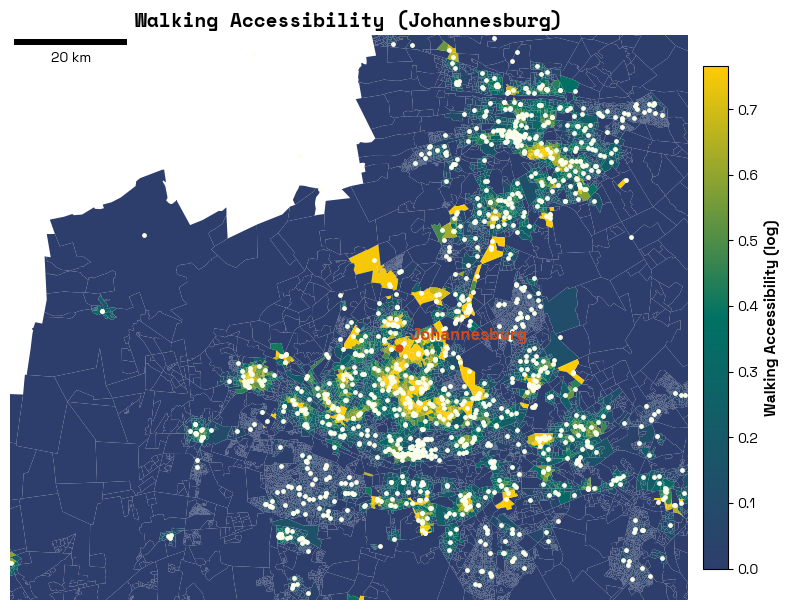

In [12]:
# Frame on the shared Johannesburg extent so this view, the Durban view,
# and the dual side-by-side view all use the same physical map scale.
xmin, xmax, ymin, ymax = CITY_EXTENTS["Johannesburg"]
figsize = figsize_from_extent(xmin, xmax, ymin, ymax, base_in = 8)

# Clip data to the viewport before plotting.
subset_jhb = allaccess.cx[xmin:xmax, ymin:ymax]
pharm_jhb = pharm_with_sal.cx[xmin:xmax, ymin:ymax]

# Color stretched to the 2nd-98th percentile of in-view values.
vmin = subset_jhb["walk_log"].quantile(0.02)
vmax = subset_jhb["walk_log"].quantile(0.98)
norm = mpl.colors.Normalize(vmin = vmin, vmax = vmax)

fig, ax = plt.subplots(figsize = figsize)
ax.set_facecolor("#fcffeb")

subset_jhb.plot(column = "walk_log", cmap = access_cmap, norm = norm, ax = ax, edgecolor = "none")
pharm_jhb.plot(ax = ax, color = "#fcffeb", markersize = 6, alpha = 1.0, zorder = 5)

# City markers for any city inside the viewport.
extent = (xmin, xmax, ymin, ymax)
for x, y, name in visible_cities(extent, names = ["Johannesburg"]):
    ax.scatter(x, y, color = "#d14b18", s = 25, zorder = 20)
    ax.annotate(
        name,
        xy = (x, y),
        xytext = (8, 6),
        textcoords = "offset points",
        fontsize = 12,
        fontweight = "bold",
        fontname = FONT_BODY,
        zorder = 21,
        color = "#d14b18"
    )

# Lock aspect to data CRS units.
ax.set_aspect("equal")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.add_artist(ScaleBar(dx = 1, units = "m", location = "upper left"))
ax.set_title("Walking Accessibility (Johannesburg)", fontweight = "bold", fontname = FONT_TITLE)
ax.axis("off")

# Colorbar.
sm = mpl.cm.ScalarMappable(cmap = access_cmap, norm = norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax = ax, fraction = 0.035, pad = 0.02)
cbar.set_label("Walking Accessibility (log)", fontweight = "bold", fontname = FONT_BODY)

plt.tight_layout()
fig.savefig("images/2sfca/A_i_johannesburg.png", dpi = 300, bbox_inches = "tight")
fig.savefig("images/2sfca/A_i_johannesburg_transparent.png", dpi = 300, bbox_inches = "tight", transparent = True)
plt.show()

### Durban Walking Accessibility

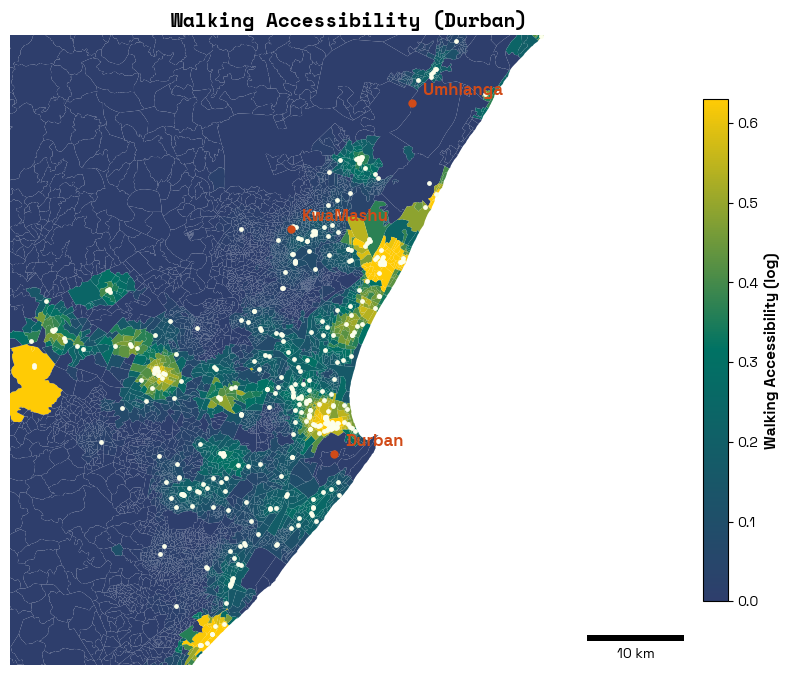

In [13]:
# Frame on the shared Durban extent so single-city and dual views match.
xmin, xmax, ymin, ymax = CITY_EXTENTS["Durban"]
figsize = figsize_from_extent(xmin, xmax, ymin, ymax, base_in = 8)

# Clip to viewport.
subset_durban = allaccess.cx[xmin:xmax, ymin:ymax]
pharm_durban = pharm_with_sal.cx[xmin:xmax, ymin:ymax]

# Color stretch on in-view percentiles.
vmin = subset_durban["walk_log"].quantile(0.02)
vmax = subset_durban["walk_log"].quantile(0.98)
norm = mpl.colors.Normalize(vmin = vmin, vmax = vmax)

fig, ax = plt.subplots(figsize = figsize)
ax.set_facecolor("#fcffeb")

subset_durban.plot(column = "walk_log", cmap = access_cmap, norm = norm, ax = ax, edgecolor = "none")
pharm_durban.plot(ax = ax, color = "#fcffeb", markersize = 6, alpha = 1.0, zorder = 5)

# City markers for any city in view.
extent = (xmin, xmax, ymin, ymax)
for x, y, name in visible_cities(extent, names = ["Durban", "Umhlanga", "KwaMashu"]):
    ax.scatter(x, y, color = "#d14b18", s = 25, zorder = 20)
    ax.annotate(
        name,
        xy = (x, y),
        xytext = (8, 6),
        textcoords = "offset points",
        fontsize = 12,
        fontweight = "bold",
        fontname = FONT_BODY,
        zorder = 21,
        color = "#d14b18"
    )

ax.set_aspect("equal")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.add_artist(ScaleBar(dx = 1, units = "m", location = "lower right"))
ax.set_title("Walking Accessibility (Durban)", fontweight = "bold", fontname = FONT_TITLE)
ax.axis("off")

sm = mpl.cm.ScalarMappable(cmap = access_cmap, norm = norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax = ax, fraction = 0.035, pad = 0.02)
cbar.set_label("Walking Accessibility (log)", fontweight = "bold", fontname = FONT_BODY)

plt.tight_layout()
fig.savefig("images/2sfca/A_i_durban.png", dpi = 300, bbox_inches = "tight")
fig.savefig("images/2sfca/A_i_durban_transparent.png", dpi = 300, bbox_inches = "tight", transparent = True)
plt.show()

### Side-by-Side: Johannesburg vs Durban Walking

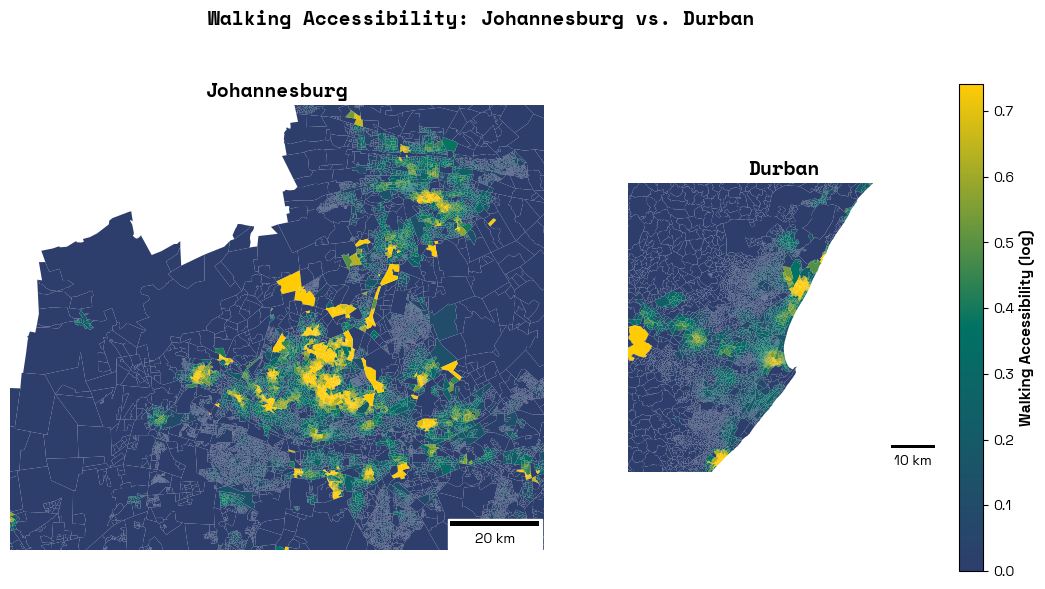

In [14]:
# Side-by-side comparison at a single shared physical scale.
# width_ratios are set to the actual extent widths (in meters) so each
# panel covers the same number of kilometers per inch of figure space.
# Without this, matplotlib gives both panels equal axes width and the
# scalebars end up reading 25 km vs 15 km for the same screen distance.

extents = {name: CITY_EXTENTS[name] for name in ["Johannesburg", "Durban"]}
widths_m = [(xmax - xmin) for (xmin, xmax, _, _) in extents.values()]
heights_m = [(ymax - ymin) for (_, _, ymin, ymax) in extents.values()]

# Pick a target physical scale (meters per figure inch).
m_per_inch = 18000
panel_widths_in = [w / m_per_inch for w in widths_m]
panel_heights_in = [h / m_per_inch for h in heights_m]

# Figure: sum of panel widths plus padding for colorbar; height fits the tallest panel.
fig_w = sum(panel_widths_in) + 2.0
fig_h = max(panel_heights_in) + 1.0

fig, axes = plt.subplots(
    1, 2,
    figsize = (fig_w, fig_h),
    gridspec_kw = {"width_ratios": panel_widths_in}
)

# Shared color stretch across both city extents for fair comparison.
all_vals = pd.concat([
    allaccess.cx[xmin:xmax, ymin:ymax]["walk_log"]
    for (xmin, xmax, ymin, ymax) in extents.values()
])
vmin = all_vals.quantile(0.02)
vmax = all_vals.quantile(0.98)
norm = mpl.colors.Normalize(vmin = vmin, vmax = vmax)

for ax, (name, (xmin, xmax, ymin, ymax)) in zip(axes, extents.items()):
    subset = allaccess.cx[xmin:xmax, ymin:ymax]
    subset.plot(column = "walk_log", cmap = access_cmap, norm = norm, ax = ax, edgecolor = "none")

    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_facecolor("#fcffeb")
    ax.add_artist(ScaleBar(dx = 1, units = "m", location = "lower right"))
    ax.set_title(name, fontweight = "bold", fontname = FONT_TITLE)
    ax.axis("off")

# Single shared colorbar.
sm = mpl.cm.ScalarMappable(norm = norm, cmap = access_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax = axes, fraction = 0.025, pad = 0.02)
cbar.set_label("Walking Accessibility (log)", fontweight = "bold", fontname = FONT_BODY)

plt.suptitle("Walking Accessibility: Johannesburg vs. Durban", size = 14, fontweight = "bold", fontname = FONT_TITLE)

fig.savefig("images/2sfca/A_i_dual.png", dpi = 300, bbox_inches = "tight")
fig.savefig("images/2sfca/A_i_dual_transparent.png", dpi = 300, bbox_inches = "tight", transparent = True)
plt.show()

### Bottom/Top 10 SAL Highlight Maps

In [64]:
def summarize_highlight(gdf, highlight_codes, score_col, label):
    """Print descriptive stats for a set of highlighted SALs.

    Parameters
    ----------
    gdf : GeoDataFrame
        Province-level slice of allaccess (already filtered to one province).
    highlight_codes : list[int]
        EA_CODE values for the highlighted SALs.
    score_col : str
        Accessibility score column, either "Ai_walk" or "Ai_drive".
    label : str
        Human-readable label for the print header.
    """
    tier_col = score_col.replace("Ai_", "") + "_tier"
    subset = gdf[gdf["EA_CODE"].isin(highlight_codes)].copy()

    if len(subset) == 0:
        print(f"WARNING: no matching SALs for {label}")
        return

    # PER-SAL DETAIL TABLE.
    detail_cols = ["EA_CODE"]

    # Add place name if available.
    if "SP_NAME" in subset.columns:
        detail_cols.append("SP_NAME")

    detail_cols.append(score_col)

    if tier_col in subset.columns:
        detail_cols.append(tier_col)

    detail_cols.extend(["sal2023_est", "area_km2"])

    if "EA_TYPE" in subset.columns:
        detail_cols.append("EA_TYPE")
    if "econ_status" in subset.columns:
        detail_cols.append("econ_status")

    # Filter to columns that actually exist.
    detail_cols = [c for c in detail_cols if c in subset.columns]
    detail = subset[detail_cols].sort_values(score_col, ascending = False)

    print(f"{label}")
    print(f"SALs matched: {len(subset)}")
    print()
    print(detail.to_string(index = False))
    print()

    # AGGREGATE SUMMARY.
    total_pop = subset["sal2023_est"].sum()
    mean_score = subset[score_col].mean()
    median_score = subset[score_col].median()
    total_area = subset["area_km2"].sum()
    mean_density = total_pop / total_area if total_area > 0 else 0

    print(f"AGGREGATE")
    print(f"Total est. population (2023): {total_pop:,.0f}")
    print(f"Total area: {total_area:,.2f} km2")
    print(f"Mean pop density: {mean_density:,.0f} per km2")
    print(f"Mean {score_col}: {mean_score:.6f}")
    print(f"Median {score_col}: {median_score:.6f}")
    print()

    # SETTLEMENT TYPE BREAKDOWN.
    if "EA_GTYPE" in subset.columns:
        print("SETTLEMENT TYPE (EA_GTYPE)")
        print(subset["EA_GTYPE"].value_counts().to_string())
        print()

    # TIER BREAKDOWN.
    if tier_col in subset.columns:
        print(f"TIER DISTRIBUTION ({tier_col})")
        print(subset[tier_col].value_counts().to_string())
        print()

In [26]:
queries = [
    ("KwaZulu-Natal", "Ai_walk", "KZN Bottom 10 Walk", False),
    ("KwaZulu-Natal", "Ai_walk", "KZN Top 10 Walk", True),
    ("KwaZulu-Natal", "Ai_drive", "KZN Bottom 10 Drive", False),
    ("KwaZulu-Natal", "Ai_drive", "KZN Top 10 Drive", True),
    ("Gauteng", "Ai_drive", "Gauteng Bottom 10 Drive", False),
    ("Gauteng", "Ai_drive", "Gauteng Top 10 Drive", True),
    ("Gauteng", "Ai_walk", "Gauteng Bottom 10 Walk", False),
    ("Gauteng", "Ai_walk", "Gauteng Top 10 Walk", True),
]

for prov_name, score_col, label, top in queries:
    cols = ["EA_CODE", score_col]
    if "SAL_NAME" in allaccess.columns:
        cols.append("SAL_NAME")
    df = allaccess[allaccess["PR_NAME"] == prov_name][cols].dropna(subset=[score_col])
    #df = df.drop_duplicates(subset="EA_CODE")
    result = df.nlargest(10, score_col) if top else df.nsmallest(10, score_col)
    codes = result["EA_CODE"].astype(int).tolist()

    print(f"{label}\n")
    print(result.to_string(index=False))
    print(f"\nhighlight_codes = {codes}\n\n")

KZN Bottom 10 Walk

 EA_CODE  Ai_walk
50310271      0.0
50310262      0.0
50310266      0.0
50310265      0.0
50310269      0.0
50310270      0.0
50310263      0.0
50310264      0.0
50310180      0.0
50310249      0.0

highlight_codes = [50310271, 50310262, 50310266, 50310265, 50310269, 50310270, 50310263, 50310264, 50310180, 50310249]


KZN Top 10 Walk

 EA_CODE   Ai_walk
54210224 17.955873
59913378  4.243730
59913388  3.762475
58610062  3.038440
57910095  2.879609
57910096  2.796816
58610061  2.625058
57910080  2.589686
58610060  2.493383
50610301  2.469042

highlight_codes = [54210224, 59913378, 59913388, 58610062, 57910095, 57910096, 58610061, 57910080, 58610060, 50610301]


KZN Bottom 10 Drive

 EA_CODE  Ai_drive
50310271       0.0
50310262       0.0
50310266       0.0
50310265       0.0
50310269       0.0
50310270       0.0
50310263       0.0
50310264       0.0
50310180       0.0
50310249       0.0

highlight_codes = [50310271, 50310262, 50310266, 50310265, 50310269, 50310270, 50

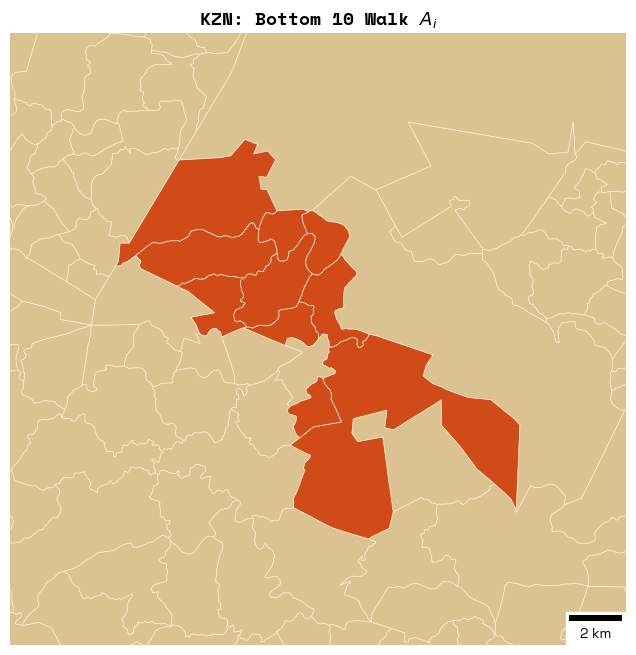

In [ ]:
# KZN BOTTOM 10 WALK.
gdf_kzn = allaccess[allaccess["PR_NAME"] == "KwaZulu-Natal"]

plot_highlight_map(
    province_gdf = gdf_kzn,
    highlight_codes = [50310271, 50310262, 50310266, 50310265, 50310269,
                       50310270, 50310263, 50310264, 50310180, 50310249],
    pharm_gdf = pharm_with_sal,
    title = "KZN: Bottom 10 Walk $A_{i}$",
    out_basename = "bottom_10_KZN_walk",
    city_names = ["Durban", "Vulamehlo", "KwaMashu", "Umhlanga"],
    show_pharmacies = True
)

In [68]:
# SUMMARY: KZN BOTTOM 10 WALK.
summarize_highlight(
    gdf = gdf_kzn,
    highlight_codes = [50310271, 50310262, 50310266, 50310265, 50310269,
                       50310270, 50310263, 50310264, 50310180, 50310249],
    score_col = "Ai_walk",
    label = "KZN: BOTTOM 10 WALK A_i"
)

KZN: BOTTOM 10 WALK A_i
SALs matched: 10

 EA_CODE          SP_NAME  Ai_walk  sal2023_est  area_km2                 EA_TYPE     econ_status
50310271 KwaMaqikizane SP      0.0   568.057138  3.900819 Traditional residential     Non_Wealthy
50310262     Mthwalume SP      0.0   352.944337  1.926623 Traditional residential     Non_Wealthy
50310266     Mthwalume SP      0.0   591.958561  1.706669 Traditional residential     Non_Wealthy
50310265     Ngomakazi SP      0.0   300.170099  4.054491 Traditional residential     Non_Wealthy
50310269     Ngomakazi SP      0.0   588.829251  2.629442 Traditional residential     Non_Wealthy
50310270     Ngomakazi SP      0.0   566.463710  5.550851 Traditional residential     Non_Wealthy
50310263    Maqikizane SP      0.0   493.166015  3.003511 Traditional residential     Non_Wealthy
50310264    Maqikizane SP      0.0   493.166015  1.721358                  Vacant Non_Residential
50310180       Nyavini SP      0.0   372.065475 22.628744                  V

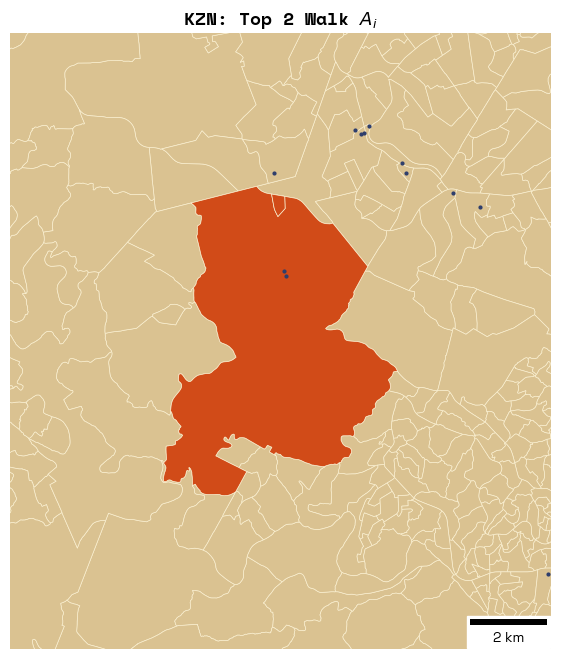

In [61]:
# KZN TOP 2 WALK.
# Selected because they are close enough together to view.
gdf_kzn = allaccess[allaccess["PR_NAME"] == "KwaZulu-Natal"]

plot_highlight_map(
    province_gdf = gdf_kzn,
    highlight_codes = [59913378, 59913388],
    pharm_gdf = pharm_with_sal,
    title = "KZN: Top 2 Walk $A_{i}$",
    out_basename = "top_2_KZN_walk",
    city_names = ["Durban", "Vulamehlo", "KwaMashu", "Umhlanga"],
    show_pharmacies = True,
)

In [69]:
# SUMMARY: KZN TOP 2 WALK.
summarize_highlight(
    gdf = gdf_kzn,
    highlight_codes = [59913378, 59913388],
    score_col = "Ai_walk",
    label = "KZN: TOP 2 WALK A_i"
)

KZN: TOP 2 WALK A_i
SALs matched: 2

 EA_CODE      SP_NAME  Ai_walk  sal2023_est  area_km2            EA_TYPE econ_status
59913378 Ethekwini NU 4.243730   187.119705 22.115493              Farms     Wealthy
59913388      Assagay 3.762475   359.532002  0.104070 Formal residential     Wealthy

AGGREGATE
Total est. population (2023): 547
Total area: 22.22 km2
Mean pop density: 25 per km2
Mean Ai_walk: 4.003102
Median Ai_walk: 4.003102

SETTLEMENT TYPE (EA_GTYPE)
EA_GTYPE
Farms    1
Urban    1



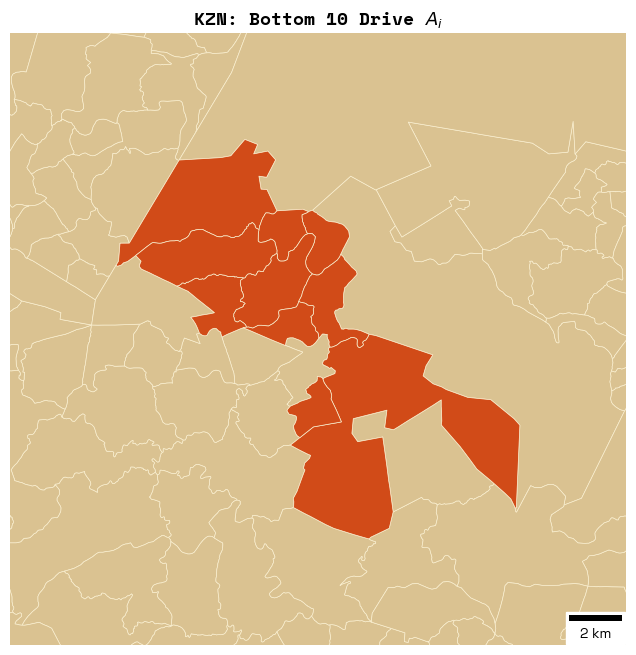

In [ ]:
# KZN BOTTOM 10 DRIVE.
# Same SALs as the walk view: every score in the drive bottom-10 is 0.0,
# and the tied SALs resolve to the same EA_CODEs as the walk version.
plot_highlight_map(
    province_gdf = gdf_kzn,
    highlight_codes = [50310271, 50310262, 50310266, 50310265, 50310269,
                       50310270, 50310263, 50310264, 50310180, 50310249],
    pharm_gdf = pharm_with_sal,
    title = "KZN: Bottom 10 Drive $A_{i}$",
    out_basename = "bottom_10_KZN_drive",
    city_names = ["Durban", "Vulamehlo", "KwaMashu", "Umhlanga"],
    show_pharmacies = False,
)

In [70]:
# SUMMARY: KZN BOTTOM 10 DRIVE.
summarize_highlight(
    gdf = gdf_kzn,
    highlight_codes = [50310271, 50310262, 50310266, 50310265, 50310269,
                       50310270, 50310263, 50310264, 50310180, 50310249],
    score_col = "Ai_drive",
    label = "KZN: BOTTOM 10 DRIVE A_i"
)

KZN: BOTTOM 10 DRIVE A_i
SALs matched: 10

 EA_CODE          SP_NAME  Ai_drive  sal2023_est  area_km2                 EA_TYPE     econ_status
50310271 KwaMaqikizane SP       0.0   568.057138  3.900819 Traditional residential     Non_Wealthy
50310262     Mthwalume SP       0.0   352.944337  1.926623 Traditional residential     Non_Wealthy
50310266     Mthwalume SP       0.0   591.958561  1.706669 Traditional residential     Non_Wealthy
50310265     Ngomakazi SP       0.0   300.170099  4.054491 Traditional residential     Non_Wealthy
50310269     Ngomakazi SP       0.0   588.829251  2.629442 Traditional residential     Non_Wealthy
50310270     Ngomakazi SP       0.0   566.463710  5.550851 Traditional residential     Non_Wealthy
50310263    Maqikizane SP       0.0   493.166015  3.003511 Traditional residential     Non_Wealthy
50310264    Maqikizane SP       0.0   493.166015  1.721358                  Vacant Non_Residential
50310180       Nyavini SP       0.0   372.065475 22.628744        

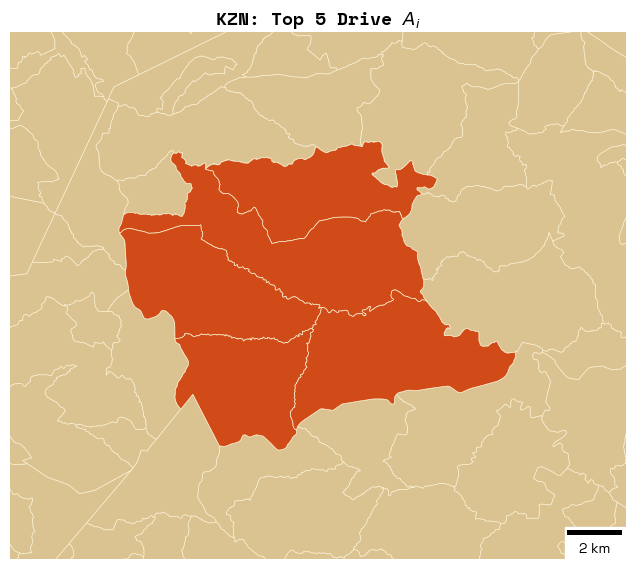

In [78]:
# KZN TOP 5 DRIVE.
plot_highlight_map(
    province_gdf = gdf_kzn,
    highlight_codes = [54210101, 54210224, 54210099, 54210230, 54210223],
    pharm_gdf = pharm_with_sal,
    title = "KZN: Top 5 Drive $A_{i}$",
    out_basename = "top_5_KZN_drive",
    city_names = ["Durban", "Vulamehlo", "KwaMashu", "Umhlanga"],
    show_pharmacies = False,
)

In [71]:
# SUMMARY: KZN TOP 10 DRIVE.
summarize_highlight(
    gdf = gdf_kzn,
    highlight_codes = [54210101, 54210224, 54210099, 54210230, 54210223],
    score_col = "Ai_drive",
    label = "KZN: TOP 10 DRIVE A_i"
)

KZN: TOP 10 DRIVE A_i
SALs matched: 5

 EA_CODE       SP_NAME  Ai_drive  sal2023_est  area_km2                 EA_TYPE econ_status
54210101    Malunga SP  3.803791   618.182235 16.826815 Traditional residential Non_Wealthy
54210224  Smukumuku SP  2.976206   334.152516 12.982436 Traditional residential Non_Wealthy
54210099  Dlaylyane SP  1.562172   164.764746 11.823550 Traditional residential Non_Wealthy
54210230  Cungewane SP  1.400569   104.003293 12.859137 Traditional residential Non_Wealthy
54210223 Emangidini SP  1.342912   660.253165 14.485124 Traditional residential Non_Wealthy

AGGREGATE
Total est. population (2023): 1,881
Total area: 68.98 km2
Mean pop density: 27 per km2
Mean Ai_drive: 2.217130
Median Ai_drive: 1.562172

SETTLEMENT TYPE (EA_GTYPE)
EA_GTYPE
Traditional    5



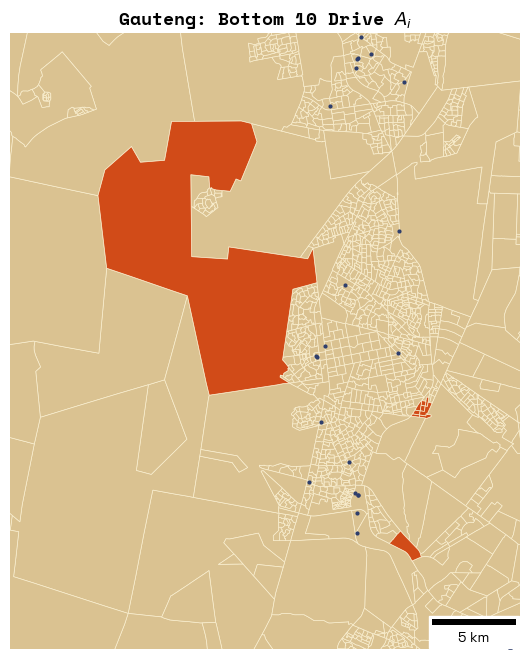

In [24]:
# GAUTENG BOTTOM 10 DRIVE.
gdf_gau = allaccess[allaccess["PR_NAME"] == "Gauteng"]

plot_highlight_map(
    province_gdf = gdf_gau,
    highlight_codes = [76010966, 76010964, 76010981, 76010976, 76010975,
                       76010969, 76011312, 76010971, 76011134, 76010668],
    pharm_gdf = pharm_with_sal,
    title = "Gauteng: Bottom 10 Drive $A_{i}$",
    out_basename = "bottom_10_Gauteng_drive",
    city_names = ["Johannesburg", "Pretoria", "Merafong City"],
    show_pharmacies = True,
)

In [74]:
# SUMMARY: GAUTENG BOTTOM 10 DRIVE.
summarize_highlight(
    gdf = gdf_gau,
    highlight_codes = [76010966, 76010964, 76010981, 76010976, 76010975,
                       76010969, 76011312, 76010971, 76011134, 76010668],
    score_col = "Ai_drive",
    label = "GAUTENG: BOTTOM 10 DRIVE A_i"
)

GAUTENG: BOTTOM 10 DRIVE A_i
SALs matched: 10

 EA_CODE      SP_NAME  Ai_drive  sal2023_est  area_km2              EA_TYPE econ_status
76010966    Eatonside       0.0   712.676868  0.051354   Formal residential     Wealthy
76010964    Eatonside       0.0   733.381548  0.087551   Formal residential     Wealthy
76010981    Eatonside       0.0   760.624548  0.058979   Formal residential     Wealthy
76010976    Eatonside       0.0   763.893708  0.058960   Formal residential     Wealthy
76010975    Eatonside       0.0   791.136707  0.066020   Formal residential     Wealthy
76010969    Eatonside       0.0   854.340466  0.069976   Formal residential     Wealthy
76011312    Eatonside       0.0   997.093784  0.062481   Formal residential     Wealthy
76010971    Eatonside       0.0   957.863864  0.085592   Formal residential     Wealthy
76011134 Sebokeng SP1       0.0  1008.357219 80.723306             Township     Wealthy
76010668   Boiketlong       0.0   345.498972  1.087766 Informal residenti

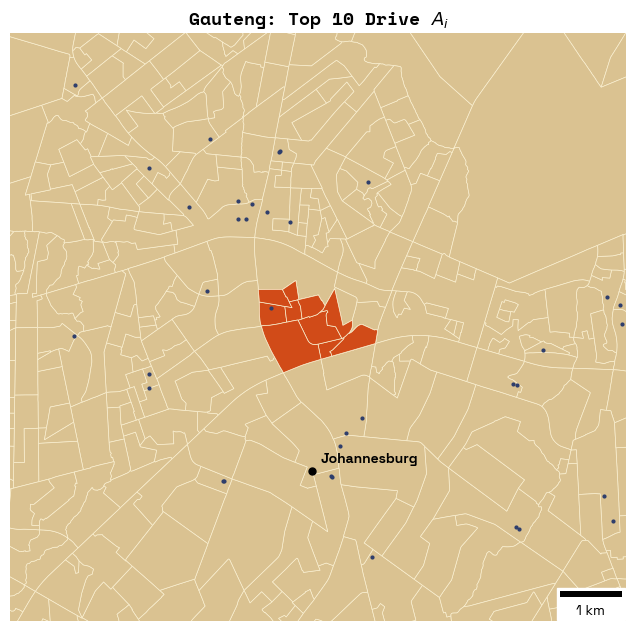

In [33]:
# GAUTENG TOP 10 DRIVE.
gdf_gau = allaccess[allaccess["PR_NAME"] == "Gauteng"]

plot_highlight_map(
    province_gdf = gdf_gau,
    highlight_codes = [79814159, 79816032, 79814156, 79816031, 79814155,
                       79814153, 79814150, 79814154, 79816010, 79814152],
    pharm_gdf = pharm_with_sal,
    title = "Gauteng: Top 10 Drive $A_{i}$",
    out_basename = "top_10_Gauteng_drive",
    city_names = ["Johannesburg", "Pretoria", "Merafong City"],
    show_pharmacies = True,
)

In [73]:
# SUMMARY: GAUTENG TOP 10 DRIVE.
summarize_highlight(
    gdf = gdf_gau,
    highlight_codes = [79814159, 79816032, 79814156, 79816031, 79814155,
                       79814153, 79814150, 79814154, 79816010, 79814152],
    score_col = "Ai_drive",
    label = "GAUTENG: TOP 10 DRIVE A_i"
)

GAUTENG: TOP 10 DRIVE A_i
SALs matched: 10

 EA_CODE     SP_NAME  Ai_drive  sal2023_est  area_km2                EA_TYPE     econ_status
79814159 Magaliessig  8.332970   120.005226  0.088521     Formal residential         Wealthy
79816032 Magaliessig  8.325770   177.981777  0.043520     Formal residential         Wealthy
79814156 Magaliessig  7.911464   191.384958  0.056187     Formal residential         Wealthy
79816031 Magaliessig  7.037235   191.384958  0.087028     Formal residential         Wealthy
79814155 Magaliessig  6.815106   120.005226  0.110221             Commercial Non_Residential
79814153 Magaliessig  6.419873   169.565826  0.177062     Formal residential         Wealthy
79814150 Magaliessig  6.040501   201.359418  0.387127     Formal residential         Wealthy
79814154 Magaliessig  5.969375   173.929652  0.120249     Formal residential         Wealthy
79816010 Magaliessig  5.727252     0.000000  0.153201 Parks and recreation_*             NaN
79814152 Magaliessig  5.63

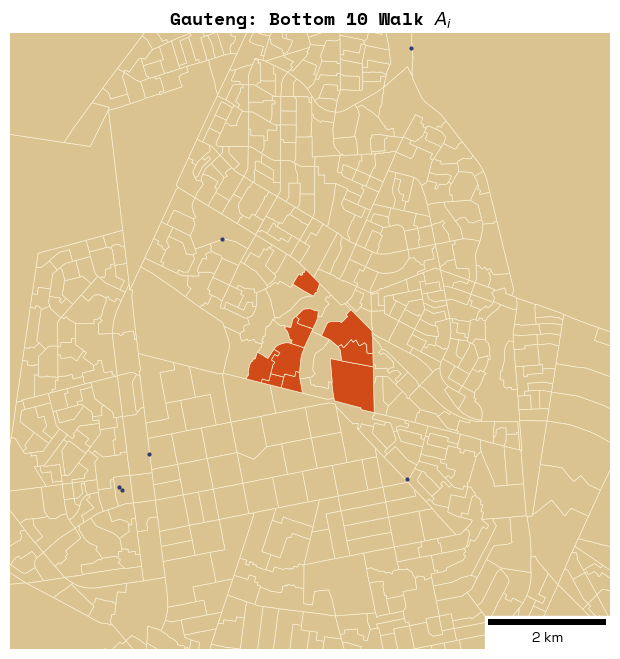

In [37]:
# GAUTENG BOTTOM 10 WALK.
plot_highlight_map(
    province_gdf = gdf_gau,
    highlight_codes = [76010955, 76011356, 76010940, 76010946, 76010952,
                       76011355, 76010947, 76011358, 76011357, 76010951],
    pharm_gdf = pharm_with_sal,
    title = "Gauteng: Bottom 10 Walk $A_{i}$",
    out_basename = "bottom_10_Gauteng_walk",
    city_names = ["Johannesburg", "Pretoria"],
    show_pharmacies = True,
)

In [77]:
# SUMMARY: GAUTENG BOTTOM 10 WALK.
summarize_highlight(
    gdf = gdf_gau,
    highlight_codes = [76010955, 76011356, 76010940, 76010946, 76010952,
                       76011355, 76010947, 76011358, 76011357, 76010951],
    score_col = "Ai_walk",
    label = "GAUTENG: BOTTOM 10 WALK A_i"
)

GAUTENG: BOTTOM 10 WALK A_i
SALs matched: 10

 EA_CODE      SP_NAME  Ai_walk  sal2023_est  area_km2            EA_TYPE econ_status
76010955 Stretford SP      0.0   783.865183  0.087199 Formal residential     Wealthy
76011356 Evaton North      0.0   698.107844  0.040418           Township Non_Wealthy
76010940 Evaton North      0.0   842.786130  0.411584           Township Non_Wealthy
76010946 Evaton North      0.0   842.786130  0.137421           Township Non_Wealthy
76010952 Evaton North      0.0   943.920466  0.070634           Township Non_Wealthy
76011355 Evaton North      0.0  1015.557287  0.065860           Township Non_Wealthy
76010947 Evaton North      0.0  1036.626940  0.120947           Township Non_Wealthy
76011358 Evaton North      0.0  1082.980177  0.189739           Township Non_Wealthy
76011357 Evaton North      0.0  1113.882335  0.132969           Township Non_Wealthy
76010951 Evaton North      0.0  1210.802740  0.102358           Township Non_Wealthy

AGGREGATE
Total es

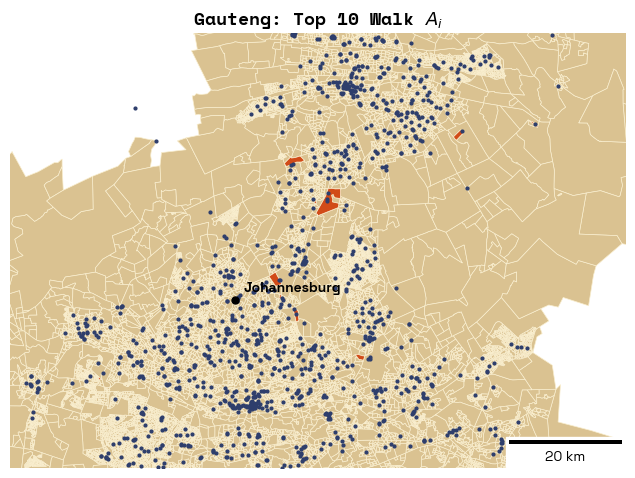

In [25]:
# GAUTENG TOP 10 WALK.
plot_highlight_map(
    province_gdf = gdf_gau,
    highlight_codes = [79710820, 79910649, 79910250, 79910810, 79815538,
                       79910793, 79911564, 76310210, 79815860, 79815868],
    pharm_gdf = pharm_with_sal,
    title = "Gauteng: Top 10 Walk $A_{i}$",
    out_basename = "top_10_Gauteng_walk",
    city_names = ["Johannesburg", "Pretoria"],
    show_pharmacies = True,
)

In [76]:
# SUMMARY: GAUTENG TOP 10 WALK.
summarize_highlight(
    gdf = gdf_gau,
    highlight_codes = [79710820, 79910649, 79910250, 79910810, 79815538,
                       79910793, 79911564, 76310210, 79815860, 79815868],
    score_col = "Ai_walk",
    label = "GAUTENG: TOP 10 WALK A_i"
)

GAUTENG: TOP 10 WALK A_i
SALs matched: 10

 EA_CODE                                SP_NAME   Ai_walk  sal2023_est  area_km2                    EA_TYPE     econ_status
79710820                                 Isando 22.391385     8.127223  0.789562                 Industrial Non_Residential
79910649                         Zwavelpoort AH  7.130249   140.247552  1.165499                 Industrial Non_Residential
79910250                  The Reeds Ext 6,19,20  5.161081   387.515695  0.119297         Formal residential         Wealthy
79910810                       Heuwelsig Estate  4.201777   261.487877  0.068579         Formal residential         Wealthy
79815538                            Frankenwald  3.972019   503.522249  1.232669                 Industrial Non_Residential
79910793                              Raslou AH  3.920595   320.283968  2.542095              Smallholdings         Wealthy
79911564                          Donkerhoek SH  3.759601   163.843726  0.306411         

### Bivariate Map: Walking vs Driving Accessibility

Each SAL is classified into a 3x3 grid based on terciles of log-transformed
walk and drive scores. Grey = low/low (most underserved), blue = high/high
(best served). Insets zoom into Johannesburg/Pretoria and Durban.

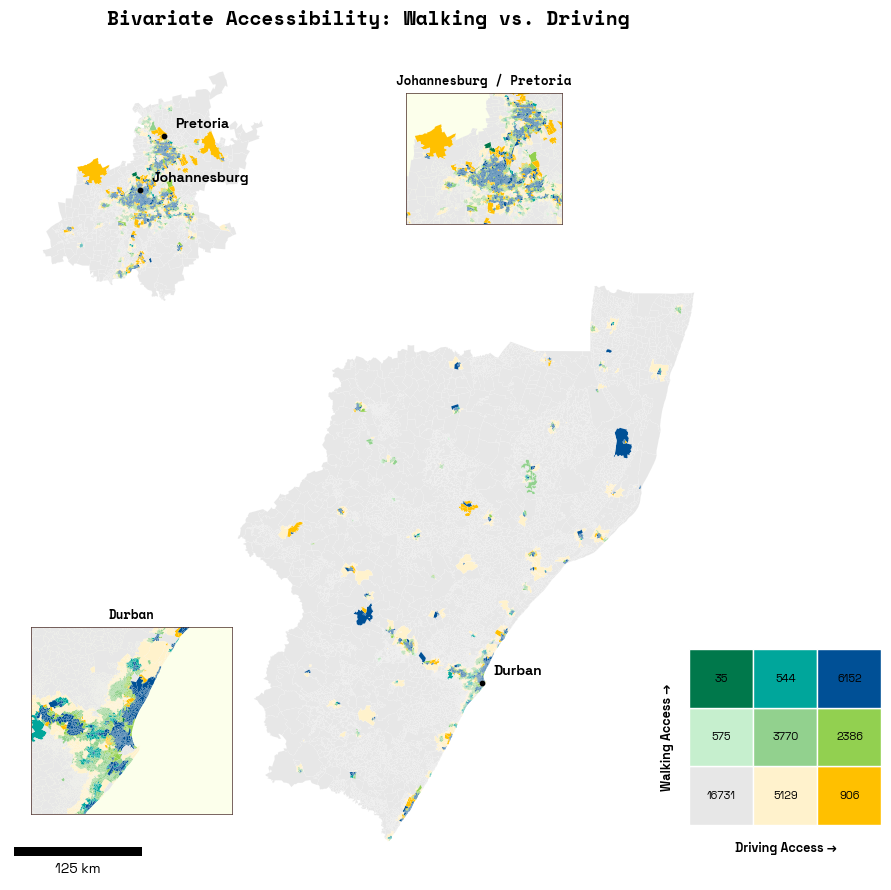

In [ ]:
# BIVARIATE WALKING vs DRIVING ACCESSIBILITY.
# Each SAL is binned into a 3x3 grid on terciles of log walk and log drive
# scores. Grey = low/low (most underserved). Insets zoom into Johannesburg
# and Durban using the shared CITY_EXTENTS so framing matches earlier maps.

# Data CRS is already EPSG:3857 from the data prep cell above.
# Tercile bins computed on the positive-score subset.
allaccess["walk_q"] = 0
mask = allaccess["walk_log"] > 0
allaccess.loc[mask, "walk_q"] = pd.qcut(allaccess.loc[mask, "walk_log"], 3, labels = [0, 1, 2])

allaccess["drive_q"] = 0
mask = allaccess["drive_log"] > 0
allaccess.loc[mask, "drive_q"] = pd.qcut(allaccess.loc[mask, "drive_log"], 3, labels = [0, 1, 2])

# 3x3 bivariate palette: grey corner low/low, blue corner high/high.
biv_colors = {
    (0, 0): "#E7E7E7",
    (0, 1): "#FFF2CC", (0, 2): "#FFC000",
    (1, 0): "#C6EFCE", (1, 1): "#92D18E", (1, 2): "#92D050",
    (2, 0): "#00784B", (2, 1): "#00A69B", (2, 2): "#005096",
}
allaccess["biv_color"] = allaccess.apply(
    lambda r: biv_colors[(int(r["walk_q"]), int(r["drive_q"]))],
    axis = 1
)
counts = pd.crosstab(allaccess["walk_q"], allaccess["drive_q"])

fig, ax = plt.subplots(figsize = (12, 11))
ax.set_facecolor("#fcffeb")
allaccess.plot(color = allaccess["biv_color"], ax = ax, linewidth = 0.05, edgecolor = "white")

# City labels visible at province scale.
for x, y, name in visible_cities(
    extent = ax.get_xlim() + ax.get_ylim(),
    names = ["Johannesburg", "Pretoria", "Durban"]
):
    ax.scatter(x, y, color = "black", s = 10, zorder = 20)
    ax.annotate(
        name,
        xy = (x, y),
        xytext = (8, 6),
        textcoords = "offset points",
        fontsize = 10,
        fontweight = "bold",
        fontname = FONT_BODY,
    )

ax.set_aspect("equal")
ax.set_title("Bivariate Accessibility: Walking vs. Driving", fontsize = 14, fontweight = "bold", fontname = FONT_TITLE)
ax.axis("off")
ax.add_artist(ScaleBar(dx = 1, units = "m", location = "lower left"))

# Bivariate legend grid in the lower-right.
legend_ax = fig.add_axes([0.78, 0.16, 0.16, 0.16])
legend_ax.set_facecolor("none")
legend_ax.axis("off")
for i in range(3):
    for j in range(3):
        rect = mpatches.Rectangle((j, i), 1, 1, facecolor = biv_colors[(i, j)], edgecolor = "white")
        legend_ax.add_patch(rect)
        value = counts.loc[i, j] if (i in counts.index and j in counts.columns) else 0
        legend_ax.text(j + 0.5, i + 0.5, f"{value}", ha = "center", va = "center", fontsize = 8, fontname = FONT_BODY)
legend_ax.set_xlim(0, 3)
legend_ax.set_ylim(0, 3)
legend_ax.text(1.5, -0.45, "Driving Access \u2192", ha = "center", fontsize = 9, fontname = FONT_BODY, fontweight = "bold")
legend_ax.text(-0.45, 1.5, "Walking Access \u2192", va = "center", rotation = 90, fontsize = 9, fontname = FONT_BODY, fontweight = "bold")

# Inset: Johannesburg, framed on shared CITY_EXTENTS.
jhb_xmin, jhb_xmax, jhb_ymin, jhb_ymax = CITY_EXTENTS["Johannesburg"]
axins_jhb = inset_axes(
    ax, width = "28%", height = "28%",
    loc = "upper right",
    bbox_to_anchor = (0, 0, 0.78, 1),
    bbox_transform = ax.transAxes,
)
jhb_clip = allaccess.cx[jhb_xmin:jhb_xmax, jhb_ymin:jhb_ymax]
jhb_clip.plot(color = jhb_clip["biv_color"], ax = axins_jhb, linewidth = 0.05, edgecolor = "white")
axins_jhb.set_aspect("equal")
axins_jhb.set_xlim(jhb_xmin, jhb_xmax)
axins_jhb.set_ylim(jhb_ymin, jhb_ymax)
#axins_jhb.set_facecolor("#fcffeb")
axins_jhb.set_xticks([])
axins_jhb.set_yticks([])
axins_jhb.set_title("Johannesburg / Pretoria", fontsize = 9, fontname = FONT_TITLE, fontweight = "bold")
for spine in axins_jhb.spines.values():
    spine.set_edgecolor("#442520")
    spine.set_linewidth(0.5)

# Inset: Durban, framed on shared CITY_EXTENTS.
dur_xmin, dur_xmax, dur_ymin, dur_ymax = CITY_EXTENTS["Durban"]
axins_dur = inset_axes(
    ax, width = "28%", height = "28%",
    loc = "lower left",
    bbox_to_anchor = (0.02, 0.04, 1, 1),
    bbox_transform = ax.transAxes,
)
dur_clip = allaccess.cx[dur_xmin:dur_xmax, dur_ymin:dur_ymax]
dur_clip.plot(color = dur_clip["biv_color"], ax = axins_dur, linewidth = 0.05, edgecolor = "white")
axins_dur.set_aspect("equal")
axins_dur.set_xlim(dur_xmin, dur_xmax)
axins_dur.set_ylim(dur_ymin, dur_ymax)
#axins_dur.set_facecolor("#fcffeb")
axins_dur.set_xticks([])
axins_dur.set_yticks([])
axins_dur.set_title("Durban", fontsize = 9, fontname = FONT_TITLE, fontweight = "bold")
for spine in axins_dur.spines.values():
    spine.set_edgecolor("#442520")
    spine.set_linewidth(0.5)

fig.savefig("images/2sfca/bivariate_walk_drive.png", dpi = 300, bbox_inches = "tight")
fig.savefig("images/2sfca/bivariate_walk_drive_transparent.png", dpi = 300, bbox_inches = "tight", transparent = True)
plt.show()

## NOTES AND LIMITATIONS

#### **Why two metrics are necessary (this notebook and `network_threshold.ipynb`).**

The 2SFCA $A_{i}$ score and the network k = 1 distance threshold answer different questions and have opposing failures, and *neither are sufficient alone*.

| Dimension | 2SFCA $A_{i}$ | Network Distance (k = 1) |
|---|---|---|
| What it measures. | Supply-to-demand ratio within catchment, decay-weighted. | Absolute distance on road network to nearest pharmacy. |
| Output scale. | Relative, so **only meaningful within province and travel mode**. | Absolute in meters/km, **cross-province comparable**. |
| What zeros mean. | No pharmacy reachable within catchment radius. | Does not produce zeros, always returns a finite distance. |
| High score pathology. | **Inflated by low-demand areas** (industrial, farms, sparse rural), could consider using different thresholds for EA_TYPEs, but adds complexity. | None, short distance is always genuinely short. |
| Demand pressure captured. | Yes, competing population in Step 1 denominator. | No. |
| Supply concentration visible. | Yes, one overwhelmed pharmacy scores lower than three dispersed ones. | No, only distance to nearest. |
| Zero-inflation problem. | Severe as **more than half of KZN walk SALs score exactly 0**. | Not applicable. |
| Modal dependency. | Walk and drive modeled separately. | Walk, drive, and Euclidean modeled separately. |
| Apartheid spatial signal. | Indirect via inherited pharmacy distribution. | More direct, rural SALs show largest absolute distances. |

**The k=3 distance metric addresses the floor problem** by providing an absolute, non-relative measure of how far a SAL sits from any pharmacy at all. When the $A_{i}$ is zero, the distance score tells you whether the SAL is zero because it is genuinely isolated (large distance) or because the road-network connectivity broke down near the catchment boundary (short distance but still zero $A_{i}$, which is a data quality flag, not a real desert). When the $A_{i}$ is artificially high (low-demand near-supply artifacts), the distance score anchors interpretation: **a SAL with a high $A_{i}$ but a long absolute distance is not genuinely accessible**.

---

#### **Access typology on combining $A_{i}$ w/ distance threshold.**

For the integration notebook `combine_access_score_network_threshold.ipynb`, the combination of these two metrics produces four interpretable quadrant types. The thresholds used below are the policy-relevant reference points from the network threshold notebook (3 km walk, 10 km drive).

| | Distance < threshold (pharmacy nearby) | Distance ≥ threshold (pharmacy far) |
|---|---|---|
| **$A_{i} = 0$** | Connectivity gap as pharmacy exists nearby but is road-network unreachable from this SAL. Likely an OSM completeness issue or a catchment boundary edge case. Warrants spot-check. | **True pharmacy desert** so no pharmacy reachable on the network and nearest pharmacy is also far in absolute terms. Primary NHI infrastructure target. |
| **$A_{i}$ low (bottom tercile, nonzero)** | Demand overcrowding where pharmacy is nearby but the supply-to-demand ratio is poor. Pharmacy exists but is serving a large population. Candidate for NHI capacity investment at the existing site. | Access gap, so far from a pharmacy and that pharmacy is also under-supplied relative to demand. Secondary infrastructure target. |
| **$A_{i}$ high (top tercile)** | Genuinely well-served w/ pharmacy nearby and the supply-to-demand ratio is favorable. | Artifact zone, so high $A_{i}$ is mechanically driven by low local demand (industrial, sparsely populated rural). Resident is actually far from a pharmacy. Score is not policy-relevant, so use distance as primary indicator. |

The artifact zone (high $A_{i}$, far distance) accounts for the pathological top-scoring SALs in both provinces: Isando and Zwavelpoort in Gauteng walk, and the Malunga/Smukumuku cluster in KZN drive. These should be flagged and excluded from the "well-served" narrative.

---

#### **Side-by-side numbers to know what each metric says about the same population.**

All figures from executed notebook outputs. Percentages are SAL-count-based unless marked (pop).

| Province | Mode | $A_{i}$: % Pharmacy Desert | Distance: % exceeding policy threshold | Policy threshold used |
|---|---|---|---|---|
| Gauteng | Walk | 53.2% | 24.6% (25.7% pop-weighted) | 3 km walk |
| KwaZulu-Natal | Walk | 74.3% | 63.1% (63.2% pop-weighted) | 3 km walk |
| Gauteng | Drive | 38.7% | 2.1% (1.1% pop-weighted) | 10 km drive |
| KwaZulu-Natal | Drive | 58.8% | 38.5% (35.4% pop-weighted) | 10 km drive |

The gap between the $A_{i}$ desert rate and the distance exceedance rate is the most informative number in this table bc for Gauteng walk, 53.2% of SALs are in the Pharmacy Desert tier but only 24.6% exceed 3 km. That 28-point gap is almost entirely zero-inflation where SALs that technically have *some* pharmacy within 2 km of their centroid but whose $A_{i}$ is zero because the nearest-node snap may have placed them outside any pharmacy's catchment. These are not true deserts in the same sense as Evaton North (dense, zero $A_{i}$, short distance but overwhelmed nearby pharmacy). The $A_{i}$ tier classification obscures this.

For KZN drive, the gap narrows to 20 points (58.8% desert tier, 38.5% exceeding 10 km). This is a more honest match as KZN drive deserts may be more likely to be genuinely isolated and not snap artifacts. The median drive distance for Traditional settlement KZN is 18.7 km, which is well beyond the 10 km policy threshold.

**Settlement type breakdown at policy thresholds** (from `network_threshold.ipynb`):

| Settlement | Province | % exceeding 3 km walk | % exceeding 10 km drive |
|---|---|---|---|
| Urban | Gauteng | ~17% | ~2% |
| Urban | KZN | ~25–30% | ~15% |
| Traditional | Gauteng | ~40–50% | ~5% |
| Traditional | KZN | ~75–80% | ~50% |
| Farms | Gauteng | ~60% | ~10% |
| Farms | KZN | ~80%+ | ~50%+ |

**Economic status breakdown at policy thresholds** (from `network_threshold.ipynb`, SAL-level):

| Status | Province | % exceeding 3 km walk | % exceeding 10 km drive |
|---|---|---|---|
| Wealthy | Gauteng | 17.6% | 2.8% |
| Non_Wealthy | Gauteng | 29.8% | 1.3% |
| Wealthy | KZN | 39.6% | 15.4% |
| Non_Wealthy | KZN | 74.9% | 49.6% |

The Non_Wealthy/Traditional KZN combination is the equity signal that directly connects to apartheid-era spatial planning. These households face the largest absolute distances and, per the $A_{i}$ scores, have essentially no pharmacy access on either walking or driving networks within the policy thresholds. These are also the areas least likely to have private vehicle access, meaning the drive score is aspirational rather than descriptive for them.